## Assignment : 14

<pre>
1. Preprocess all the Data we have in DonorsChoose <a href='https://drive.google.com/drive/folders/1MIwK7BQMev8f5CbDDVNLPaFGB32pFN60'>Dataset</a> use train.csv
2. Combine 4 essay's into one column named - 'preprocessed_essays'. 
3. After step 2 you have to train 3 types of models as discussed below. 
4. For all the model use <a href='https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics'>'auc'</a> as a metric. check <a href='https://datascience.stackexchange.com/a/20192'>this</a> for using auc as a metric 
5. You are free to choose any number of layers/hiddden units but you have to use same type of architectures shown below. 
6. You can use any one of the optimizers and choice of Learning rate and momentum, resources: <a href='http://cs231n.github.io/neural-networks-3/'>cs231n class notes</a>, <a href='https://www.youtube.com/watch?v=hd_KFJ5ktUc'>cs231n class video</a>. 
7. For all the model's use <a href='https://www.youtube.com/watch?v=2U6Jl7oqRkM'>TensorBoard</a> and plot the Metric value and Loss with epoch. While submitting, take a screenshot of plots and include those images in .ipynb notebook and PDF. 
8. Use Categorical Cross Entropy as Loss to minimize.
</pre>

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
from sklearn.feature_extraction.text import CountVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
count_vect = CountVectorizer()
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
from sklearn.preprocessing import StandardScaler
standardizer = StandardScaler()
import keras
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold 
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import MaxPooling1D,Conv1D,Flatten,Concatenate,Dropout,Dense,Input
from tensorflow.keras import layers,Model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import f1_score
import math
from tensorflow.keras.layers import Embedding
from tensorflow.keras.backend import backend
import pickle
from sklearn.feature_extraction.text import CountVectorizer
import re
# Tutorial about Python regular expressions: https://pymotw.com/2/re/

from nltk.corpus import stopwords
import pickle

from tqdm import tqdm
import os

### Model-1

Build and Train deep neural network as shown below

<img src='https://i.imgur.com/w395Yk9.png'>
ref: https://i.imgur.com/w395Yk9.png

- __Input_seq_total_text_data__ --- You have to give Total text data columns. After this use the Embedding layer to get word vectors. Use given predefined glove word vectors, don't train any word vectors. After this use LSTM and get the LSTM output and Flatten that output. 
- __Input_school_state__ --- Give 'school_state' column as input to embedding layer and Train the Keras Embedding layer. 
- __Project_grade_category__  --- Give 'project_grade_category' column as input to embedding layer and Train the Keras Embedding layer.
- __Input_clean_categories__ --- Give 'input_clean_categories' column as input to embedding layer and Train the Keras Embedding layer.
- __Input_clean_subcategories__ --- Give 'input_clean_subcategories' column as input to embedding layer and Train the Keras Embedding layer.
- __Input_clean_subcategories__ --- Give 'input_teacher_prefix' column as input to embedding layer and Train the Keras Embedding layer.
- __Input_remaining_teacher_number_of_previously_posted_projects._resource_summary_contains_numerical_digits._price._quantity__ ---concatenate remaining columns and add a Dense layer after that. 



- For LSTM, you can choose your sequence padding methods on your own or you can train your LSTM without padding, there is no restriction on that.

Below is an example of embedding layer for a categorical columns. In below code all are dummy values, we gave only for referance. 

# Reading Data

In [3]:
project_data = pd.read_csv('/content/gdrive/My Drive/train_data.csv')
resource_data = pd.read_csv('/content/gdrive/My Drive/resources.csv')

# Preprocessing Uncleaned Data

In [5]:
# https://stackoverflow.com/questions/36383821/pandas-dataframe-apply-function-to-column-strings-based-on-other-column-value
project_data['project_grade_category'] = project_data['project_grade_category'].str.replace(' ','_')
project_data['project_grade_category'] = project_data['project_grade_category'].str.replace('-','_')
project_data['project_grade_category'] = project_data['project_grade_category'].str.lower()
#project_data['project_grade_category'].value_counts()




In [6]:
project_data['project_subject_categories'] = project_data['project_subject_categories'].str.replace(' The ','')
project_data['project_subject_categories'] = project_data['project_subject_categories'].str.replace(' ','')
project_data['project_subject_categories'] = project_data['project_subject_categories'].str.replace('&','_')
project_data['project_subject_categories'] = project_data['project_subject_categories'].str.replace(',','_')
project_data['project_subject_categories'] = project_data['project_subject_categories'].str.lower()

In [7]:
project_data['project_subject_subcategories'] = project_data['project_subject_subcategories'].str.replace(' The ','')
project_data['project_subject_subcategories'] = project_data['project_subject_subcategories'].str.replace(' ','')
project_data['project_subject_subcategories'] = project_data['project_subject_subcategories'].str.replace('&','_')
project_data['project_subject_subcategories'] = project_data['project_subject_subcategories'].str.replace(',','_')
project_data['project_subject_subcategories'] = project_data['project_subject_subcategories'].str.lower()

In [8]:
project_data['teacher_prefix']=project_data['teacher_prefix'].fillna('Mrs.')
project_data['teacher_prefix'] = project_data['teacher_prefix'].str.replace('.','')
project_data['teacher_prefix'] = project_data['teacher_prefix'].str.lower()

In [9]:
project_data['school_state'] = project_data['school_state'].str.lower()

In [10]:
project_data.columns

Index(['Unnamed: 0', 'id', 'teacher_id', 'teacher_prefix', 'school_state',
       'project_submitted_datetime', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'project_title', 'project_essay_1', 'project_essay_2',
       'project_essay_3', 'project_essay_4', 'project_resource_summary',
       'teacher_number_of_previously_posted_projects', 'project_is_approved'],
      dtype='object')

# Merging  Project Essay1,2,3&4 into single column called essay

In [11]:
project_data["essay"] = project_data["project_essay_1"].map(str) +\
                        project_data["project_essay_2"].map(str) + \
                        project_data["project_essay_3"].map(str) + \
                        project_data["project_essay_4"].map(str)

In [12]:
import re

def decontracted(phrase):
    # specific
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)

    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)
    return phrase

In [13]:
# https://gist.github.com/sebleier/554280
# we are removing the words from the stop words list: 'no', 'nor', 'not'
stopwords= ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've",\
            "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', \
            'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their',\
            'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', \
            'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', \
            'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', \
            'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after',\
            'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further',\
            'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',\
            'most', 'other', 'some', 'such', 'only', 'own', 'same', 'so', 'than', 'too', 'very', \
            's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 'd', 'll', 'm', 'o', 're', \
            've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn',\
            "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',\
            "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", \
            'won', "won't", 'wouldn', "wouldn't"]

# Defining Single Preporceess function

In [14]:
from tqdm import tqdm
def preprocess_text(text_data):
    preprocessed_text = []
    # tqdm is for printing the status bar
    for sentance in tqdm(text_data):
        sent = decontracted(sentance)
        sent = sent.replace('\\r', ' ')
        sent = sent.replace('\\n', ' ')
        sent = sent.replace('\\"', ' ')
        sent = re.sub('[^A-Za-z0-9]+', ' ', sent)
        # https://gist.github.com/sebleier/554280
        sent = ' '.join(e for e in sent.split() if e.lower() not in stopwords)
        preprocessed_text.append(sent.lower().strip())
    return preprocessed_text

In [15]:
project_data["essay"] = preprocess_text(project_data['essay'].values)

100%|██████████| 109248/109248 [00:58<00:00, 1879.23it/s]


# Grouping numeircal column

In [16]:
# https://stackoverflow.com/questions/22407798/how-to-reset-a-dataframes-indexes-for-all-groups-in-one-step
price_data = resource_data.groupby('id').agg({'price':'sum', 'quantity':'sum'}).reset_index()
project_data = pd.merge(project_data, price_data, on='id', how='left')
price_data.head(2)

,id,price,quantity
0,p000001,459.56,7
1,p000002,515.89,21


# Identifying no from project resource summary 

In [17]:
num_present_proj_resorce =[]
for sent in project_data['project_resource_summary']:
  sent = re.findall('\d+' ,sent)
  if len(sent) ==1:
    num_present_proj_resorce.append(sent[0])
  elif len(sent) ==0:
    num_present_proj_resorce.append(0)
  else:
    num_present_proj_resorce.append(sent)
project_data['project_resource_summary_numerics'] =num_present_proj_resorce

In [18]:
project_data.drop(['Unnamed: 0','id','teacher_id','project_submitted_datetime','project_title',
                   'project_essay_1','project_essay_2','project_essay_3','project_essay_4',
                   'project_resource_summary'],axis=1, inplace=True)

In [19]:
project_data.columns

Index(['teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'project_is_approved',
       'essay', 'price', 'quantity', 'project_resource_summary_numerics'],
      dtype='object')

# Splitting Train and Test data

In [20]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
X_train, X_test, y_train, y_test = train_test_split(
      project_data.drop(['project_is_approved'],axis=1),project_data['project_is_approved'] , 
      test_size=0.25, stratify=project_data['project_is_approved'])
Y_train = tf.keras.utils.to_categorical(y_train, 2) 
Y_test = tf.keras.utils.to_categorical(y_test, 2)

In [21]:
X_train.columns

Index(['teacher_prefix', 'school_state', 'project_grade_category',
       'project_subject_categories', 'project_subject_subcategories',
       'teacher_number_of_previously_posted_projects', 'essay', 'price',
       'quantity', 'project_resource_summary_numerics'],
      dtype='object')

# Tokenize essay with around 5500 word .As the max length of essay column is 320 so we consider 320 as maximum length during padding

In [ ]:

tokenize_word =tf.keras.preprocessing.text.Tokenizer(
    num_words=5500)
tokenize_word.fit_on_texts(X_train["essay"])
length_of_vocab = len(tokenize_word.index_word) +1
print(length_of_vocab)
X_train_encoded_sequence = tokenize_word.texts_to_sequences(X_train["essay"]) 
X_train_essay_pad = tf.keras.preprocessing.sequence.pad_sequences(X_train_encoded_sequence,maxlen=320,padding='post')
X_test_encoded_sequence = tokenize_word.texts_to_sequences(X_test["essay"]) 
X_test_essay_pad = tf.keras.preprocessing.sequence.pad_sequences(X_test_encoded_sequence,maxlen=320,padding='post')



50271


# Creating embeded Vector

In [ ]:
with open('/content/gdrive/My Drive/glove_vectors', 'rb') as f:
    model = pickle.load(f)
    glove_words =  set(model.keys())
#below code is referred from source https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/
embedding_matrix_essay = np.zeros((length_of_vocab, 300))
for word, i in tokenize_word.word_index.items():
	embedding_vector = model.get(word)
	if embedding_vector is not None:
		embedding_matrix_essay[i] = embedding_vector

# Embeddig logic for categorical variable

In [22]:
def cat_embedding(train,test):
  train_dict = dict((value,index) for index,value in enumerate(train.unique()))
  #print(train_dict,"train_dict")  
  train_dict['notseen'] = len(train_dict)
  size_train_vocab = len(train_dict)+1 
  size_train_unique = len(train_dict)
  cat_embed_matrix = np.zeros((size_train_vocab,len(train_dict)))
  #print(cat_embed_matrix.shape)
  #print(train_dict,"TD")  
  cv = CountVectorizer()
  cv.fit(np.array(list(train_dict.keys())))
  for index,value in train_dict.items():
    cat_embed_matrix[value] = cv.transform([index]).toarray()[0]
  train = train.map(lambda x : train_dict.get(x) if train_dict.get(x) else train_dict.get('notseen'))
  test = test.map(lambda x : train_dict.get(x) if train_dict.get(x) else train_dict.get('notseen'))
  return np.array(train),np.array(test),size_train_vocab,size_train_unique,cat_embed_matrix 

In [23]:
sch_st_train,sch_st_test,sch_st_vocab,sch_st_uniq,sch_st_emtrix  = cat_embedding(X_train['school_state'],X_test['school_state'])
proj_grad_train,proj_grad_test,proj_grad_vocab,proj_grad_uniq,proj_grad_emtrix = cat_embedding(X_train['project_grade_category'],X_test['project_grade_category'])
proj_sub_cat_train,proj_sub_cat_test,proj_sub_cat_vocab,proj_sub_cat_uniq,proj_sub_cat_emtrix = cat_embedding(X_train['project_subject_categories'],X_test['project_subject_categories'])
proj_sub_subcat_train,proj_sub_subcat_test,proj_sub_subcat_vocab,proj_sub_subcat_uniq,proj_sub_subcat_emtrix = cat_embedding(X_train['project_subject_subcategories'],X_test['project_subject_subcategories'])
teach_prfx_train,teach_prfx_test,teach_prfx_vocab,teach_prfx_uniq,teach_prfx_emtrix      = cat_embedding(X_train['teacher_prefix'],X_test['teacher_prefix'])

# Merging all numerical into single column

In [24]:

numeric_list_train = []  
numeric_list_train_len =[]                                   
for val1,val2,val3,val4 in zip(X_train['teacher_number_of_previously_posted_projects'],X_train['price'],X_train['quantity'],X_train['project_resource_summary_numerics']):
  no_list =[]  
  no_list.extend([val1,val2,val3])
  if isinstance(val4,list): 
    no_list.extend(val4)
  else:
    no_list.extend([val4])
  numeric_list_train.append(no_list)
  numeric_list_train_len.append(len(no_list))
  

In [25]:
print('Maximum list length in X-train',max(numeric_list_train_len))
X_train_num_padded = tf.keras.preprocessing.sequence.pad_sequences(numeric_list_train, maxlen=max(numeric_list_train_len), padding='post')

Maximum list length in X-train 18


In [26]:

numeric_list_test = []  
numeric_list_test_len =[]
                                  
for val1,val2,val3,val4 in zip(X_test['teacher_number_of_previously_posted_projects'],X_test['price'],X_test['quantity'],X_test['project_resource_summary_numerics']):
  no_list =[]  
  no_list.extend([val1,val2,val3])
  if isinstance(val4,list): 
    no_list.extend(val4)
  else:
    no_list.extend([val4])
  numeric_list_test.append(no_list)
  numeric_list_test_len.append(len(no_list))
  

In [27]:
print('Maximum list length in X-train',max(numeric_list_test_len))

Maximum list length in X-train 29


In [28]:


X_test_num_padded = tf.keras.preprocessing.sequence.pad_sequences(numeric_list_test, maxlen=29, padding='post')


# functionality of auroc

In [ ]:
from sklearn.metrics import roc_auc_score
def auroc(y_true,y_pred):
  return tf.py_function(roc_auc_score,(y_true,y_pred),tf.double)

# Call back list for model1

In [ ]:
import datetime
L=1 
filepath="best_model_{L}.h5".format(L=L)
checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_acc',  verbose=1, save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_acc', min_delta=0, patience=1, verbose=1)
log_dir= "logs_1"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)
callback_list = [checkpoint,earlystop,tensorboard_callback]


# Model 1 architecture

In [ ]:
from tensorflow.keras.layers import add
tf.keras.backend.clear_session()
Input_layer_1 = Input(shape=(320,),name="essay") #each sentence is of length 320
Embed_1   = Embedding(length_of_vocab, 300, weights=[embedding_matrix_essay], input_length=320, trainable=False)(Input_layer_1)
lstm        = layers.LSTM(128,return_sequences=True)(Embed_1)
Flatten_1     = Flatten()(lstm)

Input_layer_2 = Input(shape=(1,),name="school_state") 
Embed_2   = Embedding(sch_st_vocab,sch_st_uniq, weights=[sch_st_emtrix], input_length=1, trainable=True)(Input_layer_2)
Flatten_2     = Flatten()(Embed_2)

Input_layer_3 = Input(shape=(1,),name="proj_grade") 
Embed_3   = Embedding(proj_grad_vocab,proj_grad_uniq, weights=[proj_grad_emtrix], input_length=1, trainable=True)(Input_layer_3)
Flatten_3     = Flatten()(Embed_3)

Input_layer_4 = Input(shape=(1,),name="proj_cat") 
Embed_4   = Embedding(proj_sub_cat_vocab,proj_sub_cat_uniq, weights=[proj_sub_cat_emtrix], input_length=1, trainable=True)(Input_layer_4)
Flatten_4     = Flatten()(Embed_4)

Input_layer_5 = Input(shape=(1,),name="proj_subcat") 
Embed_5   = Embedding(proj_sub_subcat_vocab,proj_sub_subcat_uniq, weights=[proj_sub_subcat_emtrix], input_length=1, trainable=True)(Input_layer_5)
Flatten_5     = Flatten()(Embed_5)

Input_layer_6 = Input(shape=(1,),name="teacher_pref") 
Embed_6   = Embedding(teach_prfx_vocab,teach_prfx_uniq, weights=[teach_prfx_emtrix], input_length=1, trainable=True)(Input_layer_6)
Flatten_6     = Flatten()(Embed_6)

Input_layer_7 = Input(shape=(29,),name="no_feat") 
Dense_1       = Dense(256, activation='relu')(Input_layer_7)
All_flatten = [Flatten_1,Flatten_2,Flatten_3,Flatten_4,Flatten_5,Flatten_6]
Concat     = Concatenate(axis=1)(All_flatten)

Dense_2       = Dense(128,activation='relu')(Concat)

Dense_3       = Dense(96,activation='relu')(Dense_2)


Output        = Dense(2,activation='softmax',name="output")(Dense_3)
All_input = [Input_layer_1,Input_layer_2,Input_layer_3,Input_layer_4,Input_layer_5,Input_layer_6,Input_layer_7]
model_1        = Model(inputs=All_input,
                      outputs=Output)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_1.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=['acc',auroc])


X_train_all = {"essay":X_train_essay_pad,"school_state":sch_st_train,"proj_grade":proj_grad_train,"proj_cat":proj_sub_cat_train,"proj_subcat":proj_sub_subcat_train,"teacher_pref":teach_prfx_train,"no_feat":X_train_num_padded}
Y_train_all = {"output":Y_train}
X_test_all = {"essay":X_test_essay_pad,"school_state":sch_st_test,"proj_grade":proj_grad_test,"proj_cat":proj_sub_cat_test,"proj_subcat":proj_sub_subcat_test,"teacher_pref":teach_prfx_test,"no_feat":X_test_num_padded}
Y_test_all = {"output":Y_test}

model_1.fit(X_train_all,Y_train_all,epochs=20,validation_data=(X_test_all,Y_test_all), batch_size=112,callbacks=callback_list)


Epoch 1/20
731/732 [============================>.] - ETA: 0s - loss: 0.3928 - acc: 0.8501 - auroc: 0.7113
Epoch 00001: val_acc improved from -inf to 0.85069, saving model to best_model_1.h5
732/732 [==============================] - 39s 53ms/step - loss: 0.3927 - acc: 0.8502 - auroc: 0.7112 - val_loss: 0.3774 - val_acc: 0.8507 - val_auroc: 0.7326
Epoch 2/20
732/732 [==============================] - ETA: 0s - loss: 0.3591 - acc: 0.8569 - auroc: 0.7741
Epoch 00002: val_acc did not improve from 0.85069
732/732 [==============================] - 39s 53ms/step - loss: 0.3591 - acc: 0.8569 - auroc: 0.7741 - val_loss: 0.3802 - val_acc: 0.8504 - val_auroc: 0.7325
Epoch 00002: early stopping


In [ ]:
import shutil
shutil.move(log_dir,"/content/gdrive/My Drive")

'/content/gdrive/My Drive/logs_1'

# Vectorize essay 

In [66]:

vectorize_essay = vectorizer.fit(X_train["essay"].str.lower())

### 1. Go through this blog, if you have any doubt on using predefined Embedding values in Embedding layer - https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/
### 2. Please go through this link https://keras.io/getting-started/functional-api-guide/ and check the 'Multi-input and multi-output models' then you will get to know how to give multiple inputs. 

### Model-2

Use the same model as above but for 'input_seq_total_text_data' give only some words in the sentance not all the words. Filter the words as below. 

<pre>
1. Train the TF-IDF on the Train data <br>
2. Get the idf value for each word we have in the train data. <br>
3. Remove the low idf value and high idf value words from our data. Do some analysis on the Idf values and based on those values choose the low and high threshold value. Because very frequent words and very very rare words don't give much information. (you can plot a box plots and take only the idf scores within IQR range and corresponding words)<br>
4. Train the LSTM after removing the Low and High idf value words. (In model-1 Train on total data but in Model-2 train on data after removing some words based on IDF values)
</pre>

# boxplotting vectorize essay 

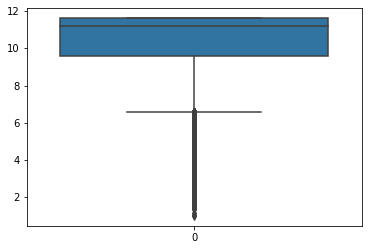

In [67]:
import seaborn as sns
sns.boxplot(data=vectorize_essay.idf_)

In [68]:
(vectorize_essay.idf_).shape

(50280,)

In [69]:
np.percentile(vectorize_essay.idf_,[5,95])

array([ 6.31476938, 11.62055876])

In [70]:
for i in range (0,101,2):
    p = np.percentile(vectorize_essay.idf_, i)
    print(str(i)+" Percentile: "+ str(p))

0 Percentile: 1.0078046427394833
2 Percentile: 5.012949627540529
4 Percentile: 5.935551632344271
6 Percentile: 6.6438250152948655
8 Percentile: 7.160414343777607
10 Percentile: 7.595207066980291
12 Percentile: 7.931679303601504
14 Percentile: 8.23719416037123
16 Percentile: 8.552505822581823
18 Percentile: 8.817198376808905
20 Percentile: 9.055609400253903
22 Percentile: 9.317973664721395
24 Percentile: 9.48049259421917
26 Percentile: 9.674648608660126
28 Percentile: 9.828799288487385
30 Percentile: 10.01112084528134
32 Percentile: 10.116481360939165
34 Percentile: 10.234264396595549
36 Percentile: 10.367795789220072
38 Percentile: 10.52194646904733
40 Percentile: 10.704268025841285
42 Percentile: 10.704268025841285
44 Percentile: 10.927411577155494
46 Percentile: 10.927411577155494
48 Percentile: 10.927411577155494
50 Percentile: 11.215093649607276
52 Percentile: 11.215093649607276
54 Percentile: 11.215093649607276
56 Percentile: 11.215093649607276
58 Percentile: 11.215093649607276
60

# considering the word which are having the idf in range of 10 to 90 percentile

In [71]:
from tqdm import tqdm
word_max_idf = []
for index , value in tqdm(enumerate(vectorize_essay.idf_)):
    if value > 2 and value <= 11.62:
          word_max_idf.append(vectorize_essay.get_feature_names()[index])  

50280it [19:07, 43.83it/s]


In [72]:
word_max_idf = set(word_max_idf)
print(type(word_max_idf))

<class 'set'>


In [73]:
x_train_max_idf = []
for value in X_train['essay']:
    x_train_max_idf.append(" ".join([w for w in value.split() if w in word_max_idf]))


In [74]:
x_test_max_idf = []
for value in X_test['essay']:
    x_test_max_idf.append(" ".join([w for w in value.split() if w in word_max_idf]))

# functionality which return the maximum length of high idf essay data

In [75]:
def uniq_word_idf(X):
  uniq_word_ifd = []
  len_of_each_point =[]
  for value in X:
      #uniq_word_ifd.extend(value.split())
      len_of_each_point.append(len(value.split()))
      #print(value,len(value))  
  return len(set(uniq_word_ifd)), max(len_of_each_point)

In [76]:
train_idf_uniq_word= uniq_word_idf(x_train_max_idf)
test_idf_uniq_word = uniq_word_idf(x_test_max_idf)

In [78]:
print(train_idf_uniq_word)
#val = train_idf_uniq_word[1]

(0, 283)


In [79]:
val=283

In [80]:
#print(test_idf_uniq_word)

In [81]:
#print(val)

# Maximum length of idf data column is 283 so choose 283 as maximum length of idf padded data

In [82]:
tokenize_word_idf =tf.keras.preprocessing.text.Tokenizer()
tokenize_word_idf.fit_on_texts(x_train_max_idf)
length_of_vocab_idf = len(tokenize_word_idf.index_word) +1
print(length_of_vocab_idf)
X_train_encoded_sequence_idf = tokenize_word_idf.texts_to_sequences(x_train_max_idf) 
X_train_essay_pad_idf = tf.keras.preprocessing.sequence.pad_sequences(X_train_encoded_sequence_idf,maxlen=val,padding='post')
X_test_encoded_sequence_idf = tokenize_word_idf.texts_to_sequences(x_test_max_idf) 
X_test_essay_pad_idf = tf.keras.preprocessing.sequence.pad_sequences(X_test_encoded_sequence_idf,maxlen=val,padding='post')


30522


In [83]:
len(X_train_essay_pad_idf)

81936

# Creating embedding matrix of idf data

In [84]:
with open('/content/gdrive/My Drive/glove_vectors', 'rb') as f:
    model = pickle.load(f)
    glove_words =  set(model.keys())
#below code is referred from source https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/
embedding_matrix_essay_idf = np.zeros((length_of_vocab_idf, 300))
for word, i in tokenize_word_idf.word_index.items():
	embedding_vector_idf = model.get(word)
	if embedding_vector_idf is not None:
		embedding_matrix_essay_idf[i] = embedding_vector_idf

In [85]:
from sklearn.metrics import roc_auc_score
def auroc_idf(y_true,y_pred):
  return tf.py_function(roc_auc_score,(y_true,y_pred),tf.double)

# Checkpoint and callback list of model2

In [86]:
import datetime
L=2 
filepath="best_model_{L}.h5".format(L=L)
checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_acc',  verbose=1, save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_acc', min_delta=0, patience=1, verbose=1)
log_dir= "LOG_2"
#log_dir= "logs1"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)
callback_list = [checkpoint,earlystop,tensorboard_callback]

# architecture of model 2

In [87]:
from tensorflow.keras.layers import add
tf.keras.backend.clear_session()
Input_layer_1 = Input(shape=(val,),name="essay") #each sentence is of length 320
Embed_1   = Embedding(length_of_vocab_idf, 300, weights=[embedding_matrix_essay_idf], input_length=val, trainable=False)(Input_layer_1)
lstm        = layers.LSTM(96,return_sequences=True)(Embed_1)
Flatten_1     = Flatten()(lstm)

Input_layer_2 = Input(shape=(1,),name="school_state") 
Embed_2   = Embedding(sch_st_vocab,sch_st_uniq, weights=[sch_st_emtrix], input_length=1, trainable=True)(Input_layer_2)
Flatten_2     = Flatten()(Embed_2)

Input_layer_3 = Input(shape=(1,),name="proj_grade") 
Embed_3   = Embedding(proj_grad_vocab,proj_grad_uniq, weights=[proj_grad_emtrix], input_length=1, trainable=True)(Input_layer_3)
Flatten_3     = Flatten()(Embed_3)

Input_layer_4 = Input(shape=(1,),name="proj_cat") 
Embed_4   = Embedding(proj_sub_cat_vocab,proj_sub_cat_uniq, weights=[proj_sub_cat_emtrix], input_length=1, trainable=True)(Input_layer_4)
Flatten_4     = Flatten()(Embed_4)

Input_layer_5 = Input(shape=(1,),name="proj_subcat") 
Embed_5   = Embedding(proj_sub_subcat_vocab,proj_sub_subcat_uniq, weights=[proj_sub_subcat_emtrix], input_length=1, trainable=True)(Input_layer_5)
Flatten_5     = Flatten()(Embed_5)

Input_layer_6 = Input(shape=(1,),name="teacher_pref") 
Embed_6   = Embedding(teach_prfx_vocab,teach_prfx_uniq, weights=[teach_prfx_emtrix], input_length=1, trainable=True)(Input_layer_6)
Flatten_6     = Flatten()(Embed_6)

Input_layer_7 = Input(shape=(29,),name="no_feat") 
Dense_1       = Dense(256, activation='relu')(Input_layer_7)
All_flatten = [Flatten_1,Flatten_2,Flatten_3,Flatten_4,Flatten_5,Flatten_6]
Concat     = Concatenate(axis=1)(All_flatten)

Dense_2       = Dense(128,activation='relu')(Concat)

Dense_3       = Dense(96,activation='relu')(Dense_2)


Output        = Dense(2,activation='softmax',name="output")(Dense_3)
All_input = [Input_layer_1,Input_layer_2,Input_layer_3,Input_layer_4,Input_layer_5,Input_layer_6,Input_layer_7]
model_2        = Model(inputs=All_input,
                      outputs=Output)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_2.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=['acc',auroc_idf])


X_train_all_idf = {"essay":X_train_essay_pad_idf,"school_state":sch_st_train,"proj_grade":proj_grad_train,"proj_cat":proj_sub_cat_train,"proj_subcat":proj_sub_subcat_train,"teacher_pref":teach_prfx_train,"no_feat":X_train_num_padded}
Y_train_all_idf = {"output":Y_train}
X_test_all_idf = {"essay":X_test_essay_pad_idf,"school_state":sch_st_test,"proj_grade":proj_grad_test,"proj_cat":proj_sub_cat_test,"proj_subcat":proj_sub_subcat_test,"teacher_pref":teach_prfx_test,"no_feat":X_test_num_padded}
Y_test_all_idf = {"output":Y_test}

model_2.fit(X_train_all_idf,Y_train_all_idf,epochs=20,validation_data=(X_test_all_idf,Y_test_all_idf), batch_size=112,callbacks=callback_list)


Epoch 1/20
731/732 [============================>.] - ETA: 0s - loss: 0.3898 - acc: 0.8498 - auroc_idf: 0.7130
Epoch 00001: val_acc improved from -inf to 0.85398, saving model to best_model_2.h5
732/732 [==============================] - 37s 51ms/step - loss: 0.3898 - acc: 0.8498 - auroc_idf: 0.7131 - val_loss: 0.3748 - val_acc: 0.8540 - val_auroc_idf: 0.7347
Epoch 2/20
732/732 [==============================] - ETA: 0s - loss: 0.3579 - acc: 0.8576 - auroc_idf: 0.7765
Epoch 00002: val_acc did not improve from 0.85398
732/732 [==============================] - 36s 49ms/step - loss: 0.3579 - acc: 0.8576 - auroc_idf: 0.7765 - val_loss: 0.3803 - val_acc: 0.8531 - val_auroc_idf: 0.7298
Epoch 00002: early stopping


In [ ]:
#Model1.summary()

In [88]:
import shutil
shutil.move(log_dir,"/content/gdrive/My Drive")

'/content/gdrive/My Drive/LOG_2'

### Model-3

<img src='https://i.imgur.com/fkQ8nGo.png'>
ref: https://i.imgur.com/fkQ8nGo.png


- __input_seq_total_text_data__: <br>
<pre>
    . Use text column('essay'), and use the Embedding layer to get word vectors. <br>
    . Use given predefined glove word vectors, don't train any word vectors. <br>
    . Use LSTM that is given above, get the LSTM output and Flatten that output. <br>
    . You are free to preprocess the input text as you needed. <br>
</pre>
- __Other_than_text_data__:<br>
<pre>
    . Convert all your Categorical values to onehot coded and then concatenate all these onehot vectors <br>
    . Neumerical values and use <a href='https://keras.io/getting-started/sequential-model-guide/#sequence-classification-with-1d-convolutions'>CNN1D</a> as shown in above figure. <br>
    . You are free to choose all CNN parameters like kernel sizes, stride.<br>
    
</pre>

In [ ]:
X_train.columns

# One hot encoded categrocial data

In [ ]:
count_vect = CountVectorizer()
teacher_prefix_vect_train = count_vect.fit_transform(X_train["teacher_prefix"])
teacher_prefix_vect_test = count_vect.transform(X_test["teacher_prefix"])

In [ ]:
count_vect = CountVectorizer()
school_state_vect_train = count_vect.fit_transform(X_train["school_state"])
school_state_vect_test = count_vect.transform(X_test["school_state"])

In [ ]:
count_vect = CountVectorizer()
project_grade_category_vect_train = count_vect.fit_transform(X_train["project_grade_category"])
project_grade_category_vect_test = count_vect.transform(X_test["project_grade_category"])

In [ ]:
count_vect = CountVectorizer()
project_subject_categories_vect_train = count_vect.fit_transform(X_train["project_subject_categories"])
project_subject_categories_vect_test = count_vect.transform(X_test["project_subject_categories"])

In [ ]:
count_vect = CountVectorizer()
project_subject_subcategories_vect_train = count_vect.fit_transform(X_train["project_subject_subcategories"])
project_subject_subcategories_vect_test = count_vect.transform(X_test["project_subject_subcategories"])

In [ ]:
X_train_all_in_one = np.hstack((teacher_prefix_vect_train.toarray(),
school_state_vect_train.toarray(),project_grade_category_vect_train.toarray(),
project_subject_categories_vect_train.toarray(),
project_subject_subcategories_vect_train.toarray(),X_train_num_padded))

# Merge all categorical and numerical data in a single column 

In [ ]:
X_test_all_in_one = np.hstack((teacher_prefix_vect_test.toarray(),
school_state_vect_test.toarray(),project_grade_category_vect_test.toarray(),
project_subject_categories_vect_test.toarray(),
project_subject_subcategories_vect_test.toarray(),X_test_num_padded))

In [ ]:
X_train_all_in_one = X_train_all_in_one.reshape(len(X_train_all_in_one),-1,1)
X_test_all_in_one = X_test_all_in_one.reshape(len(X_test_all_in_one),-1,1)

In [ ]:
 from sklearn.metrics import roc_auc_score
def auroc_model3(y_true,y_pred):
  return tf.py_function(roc_auc_score,(y_true,y_pred),tf.double)

# Checkpoint and call back list of model 3

In [ ]:
import datetime
L=3 
filepath="best_model_{L}.h5".format(L=L)
checkpoint = ModelCheckpoint(filepath=filepath, monitor='val_acc',  verbose=1, save_best_only=True, mode='max')
earlystop = EarlyStopping(monitor='val_acc', min_delta=0, patience=1, verbose=1)
log_dir= "log_3"
#log_dir= "logs1"
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)
callback_list = [checkpoint,earlystop,tensorboard_callback]

# Architecture of Model 3

In [ ]:
tf.keras.backend.clear_session()
Input_layer_1 = Input(shape=(320,),name="essay")
Embed_1   = Embedding(length_of_vocab, 300, weights=[embedding_matrix_essay], input_length=320, trainable=False)(Input_layer_1)
lstm       = layers.LSTM(128,return_sequences=True)(Embed_1)
Flatten_1     = Flatten()(lstm)
Input_layer_2 = Input(shape=(X_train_all_in_one.shape[1],1,),name="all_in_other_feat") 
Conv_1       = Conv1D(96, 5, activation='relu')(Input_layer_2) 
Conv_2       = Conv1D(64, 5, activation='relu')(Conv_1)
Flatten_2     = Flatten()(Conv_2)

Concat     = Concatenate(axis=1)([Flatten_1, Flatten_2])

Dense_1       = Dense(128,activation='relu')(Concat)

Dense_2       = Dense(96, activation='relu')(Dense_1)

Dense_3       = Dense(48, activation='relu')(Dense_2)

Output        = Dense(2,activation='softmax',name="output")(Dense_3)

model_3        = Model(inputs=[Input_layer_1, Input_layer_2],
                      outputs=Output)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model_3.compile(optimizer='adam', loss='binary_crossentropy',metrics=['acc',auroc_model3])

X_train_all_3= {"essay": X_train_essay_pad, "all_in_other_feat": X_train_all_in_one}

Y_train_3 = {"output":Y_train}
X_test_all_3= {"essay": X_test_essay_pad, "all_in_other_feat": X_test_all_in_one}

Y_test_3 = {"output":Y_test}

model_3.fit(X_train_all_3,Y_train_3,epochs=20,validation_data=(X_test_all_3,Y_test_3), batch_size=112,callbacks=callback_list)

Epoch 1/20
732/732 [==============================] - ETA: 0s - loss: 0.3978 - acc: 0.8475 - auroc_model3: 0.7190
Epoch 00001: val_acc improved from -inf to 0.85307, saving model to best_model_3.h5
732/732 [==============================] - 45s 61ms/step - loss: 0.3978 - acc: 0.8475 - auroc_model3: 0.7190 - val_loss: 0.3710 - val_acc: 0.8531 - val_auroc_model3: 0.7459
Epoch 2/20
731/732 [============================>.] - ETA: 0s - loss: 0.3540 - acc: 0.8586 - auroc_model3: 0.7850
Epoch 00002: val_acc did not improve from 0.85307
732/732 [==============================] - 44s 60ms/step - loss: 0.3540 - acc: 0.8587 - auroc_model3: 0.7849 - val_loss: 0.3729 - val_acc: 0.8512 - val_auroc_model3: 0.7565
Epoch 00002: early stopping


In [ ]:
import shutil
shutil.move(log_dir,"/content/gdrive/My Drive")

'/content/gdrive/My Drive/log_3'

In [ ]:
%load_ext tensorboard


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [ ]:
!kill 9804

/bin/bash: line 0: kill: (9804) - No such process


In [ ]:
#%tensorboard --logdir "./logs320201109-110933/"